In [6]:
# Install dependencies
!pip install torch torchvision scikit-learn seaborn matplotlib pandas numpy -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print("✅ Libraries loaded")

✅ Libraries loaded


In [7]:
# ── Replace this URL with YOUR raw GitHub CSV URL after uploading ──
URL = "https://raw.githubusercontent.com/thrafid/ANN-assignment/refs/heads/main/diabetes.csv"

df = pd.read_csv(URL)
print("Shape:", df.shape)
print(df.head())
print("\nMissing values:\n", df.isnull().sum())

Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0

In [8]:
# --- 1. Handle Missing Values ---
# For Diabetes dataset, zeros in medical columns are actually missing
cols_with_zeros = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

imputer = SimpleImputer(strategy='median')
df[cols_with_zeros] = imputer.fit_transform(df[cols_with_zeros])

# --- 2. Encode Categoricals (if any) ---
# Diabetes dataset has no categoricals, but handle generically:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# --- 3. Split Features / Target ---
TARGET = 'Outcome'   # ← change if using a different dataset
X = df.drop(columns=[TARGET]).values
y = df[TARGET].values

# --- 4. Stratified Train/Test Split (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

# --- 5. Feature Scaling ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Class balance (train): {np.bincount(y_train)}")

Train: (614, 8) | Test: (154, 8)
Class balance (train): [400 214]


In [9]:
def make_loaders(X_tr, y_tr, X_val, y_val, batch_size=32):
    def to_tensor(X, y):
        return TensorDataset(
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32))
    tr = DataLoader(to_tensor(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    vl = DataLoader(to_tensor(X_val, y_val), batch_size=batch_size)
    return tr, vl

# Further split train → train + validation (80/20 of train)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED)

INPUT_DIM = X_train.shape[1]
print("Input features:", INPUT_DIM)

Input features: 8


In [10]:
class ShallowNN(nn.Module):
    def __init__(self, input_dim, hidden_units=64, activation='relu'):
        super().__init__()
        act = nn.ReLU() if activation == 'relu' else nn.Sigmoid()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_units),
            act,
            nn.Linear(hidden_units, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

# --- Hyperparameter Tuning (Grid Search) ---
best_val_acc = 0
best_cfg = {}

for units in [32, 64, 128]:
    for act in ['relu', 'sigmoid']:
        for bs in [16, 32]:
            tr_ld, vl_ld = make_loaders(X_tr, y_tr, X_val, y_val, bs)
            model = ShallowNN(INPUT_DIM, units, act)
            opt   = optim.Adam(model.parameters(), lr=1e-3)
            loss_fn = nn.BCELoss()

            for _ in range(30):           # quick search epochs
                model.train()
                for Xb, yb in tr_ld:
                    opt.zero_grad()
                    loss_fn(model(Xb), yb).backward()
                    opt.step()

            model.eval()
            with torch.no_grad():
                Xv = torch.tensor(X_val, dtype=torch.float32)
                preds = (model(Xv).numpy() > 0.5).astype(int)
            acc = accuracy_score(y_val, preds)

            if acc > best_val_acc:
                best_val_acc = acc
                best_cfg = {'units': units, 'act': act, 'bs': bs}

print("✅ Best Shallow config:", best_cfg, f"| val_acc={best_val_acc:.4f}")

✅ Best Shallow config: {'units': 32, 'act': 'sigmoid', 'bs': 32} | val_acc=0.8130


In [11]:
EPOCHS = 100

tr_ld, vl_ld = make_loaders(X_tr, y_tr, X_val, y_val, best_cfg['bs'])
shallow_model = ShallowNN(INPUT_DIM, best_cfg['units'], best_cfg['act'])
opt      = optim.Adam(shallow_model.parameters(), lr=1e-3)
loss_fn  = nn.BCELoss()

shallow_hist = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(EPOCHS):
    # -- Train --
    shallow_model.train()
    t_loss, t_correct, t_total = 0, 0, 0
    for Xb, yb in tr_ld:
        opt.zero_grad()
        out  = shallow_model(Xb)
        loss = loss_fn(out, yb)
        loss.backward(); opt.step()
        t_loss += loss.item() * len(yb)
        t_correct += ((out > 0.5).float() == yb).sum().item()
        t_total   += len(yb)

    # -- Validate --
    shallow_model.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for Xb, yb in vl_ld:
            out  = shallow_model(Xb)
            loss = loss_fn(out, yb)
            v_loss += loss.item() * len(yb)
            v_correct += ((out > 0.5).float() == yb).sum().item()
            v_total   += len(yb)

    shallow_hist['train_loss'].append(t_loss / t_total)
    shallow_hist['val_loss'].append(v_loss / v_total)
    shallow_hist['train_acc'].append(t_correct / t_total)
    shallow_hist['val_acc'].append(v_correct / v_total)

print("✅ Shallow NN training complete")

✅ Shallow NN training complete


In [12]:
class DeepNN(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32),         nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

# --- Tune: learning rate, optimizer, epochs ---
best_deep_acc = 0
best_deep_cfg = {}

for lr in [1e-2, 1e-3]:
    for opt_name in ['adam', 'sgd']:
        tr_ld, vl_ld = make_loaders(X_tr, y_tr, X_val, y_val, 32)
        model = DeepNN(INPUT_DIM)
        opt_fn = (optim.Adam(model.parameters(), lr=lr)
                  if opt_name == 'adam'
                  else optim.SGD(model.parameters(), lr=lr, momentum=0.9))
        loss_fn = nn.BCELoss()

        for _ in range(40):
            model.train()
            for Xb, yb in tr_ld:
                opt_fn.zero_grad()
                loss_fn(model(Xb), yb).backward()
                opt_fn.step()

        model.eval()
        with torch.no_grad():
            Xv = torch.tensor(X_val, dtype=torch.float32)
            preds = (model(Xv).numpy() > 0.5).astype(int)
        acc = accuracy_score(y_val, preds)

        if acc > best_deep_acc:
            best_deep_acc = acc
            best_deep_cfg = {'lr': lr, 'opt': opt_name}

print("✅ Best Deep config:", best_deep_cfg, f"| val_acc={best_deep_acc:.4f}")

✅ Best Deep config: {'lr': 0.01, 'opt': 'adam'} | val_acc=0.7967


In [13]:
EPOCHS_DEEP = 150

tr_ld, vl_ld = make_loaders(X_tr, y_tr, X_val, y_val, 32)
deep_model = DeepNN(INPUT_DIM)
loss_fn    = nn.BCELoss()
optimizer  = (optim.Adam(deep_model.parameters(), lr=best_deep_cfg['lr'])
              if best_deep_cfg['opt'] == 'adam'
              else optim.SGD(deep_model.parameters(),
                             lr=best_deep_cfg['lr'], momentum=0.9))

deep_hist = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(EPOCHS_DEEP):
    deep_model.train()
    t_loss, t_correct, t_total = 0, 0, 0
    for Xb, yb in tr_ld:
        optimizer.zero_grad()
        out  = deep_model(Xb)
        loss = loss_fn(out, yb)
        loss.backward(); optimizer.step()
        t_loss += loss.item() * len(yb)
        t_correct += ((out > 0.5).float() == yb).sum().item()
        t_total   += len(yb)

    deep_model.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for Xb, yb in vl_ld:
            out  = deep_model(Xb)
            loss = loss_fn(out, yb)
            v_loss += loss.item() * len(yb)
            v_correct += ((out > 0.5).float() == yb).sum().item()
            v_total   += len(yb)

    deep_hist['train_loss'].append(t_loss / t_total)
    deep_hist['val_loss'].append(v_loss / v_total)
    deep_hist['train_acc'].append(t_correct / t_total)
    deep_hist['val_acc'].append(v_correct / v_total)

print("✅ Deep NN training complete")

✅ Deep NN training complete


In [14]:
def get_preds(model, X):
    model.eval()
    with torch.no_grad():
        probs = model(torch.tensor(X, dtype=torch.float32)).numpy()
    return probs, (probs > 0.5).astype(int)

s_probs, s_preds = get_preds(shallow_model, X_test)
d_probs, d_preds = get_preds(deep_model,   X_test)

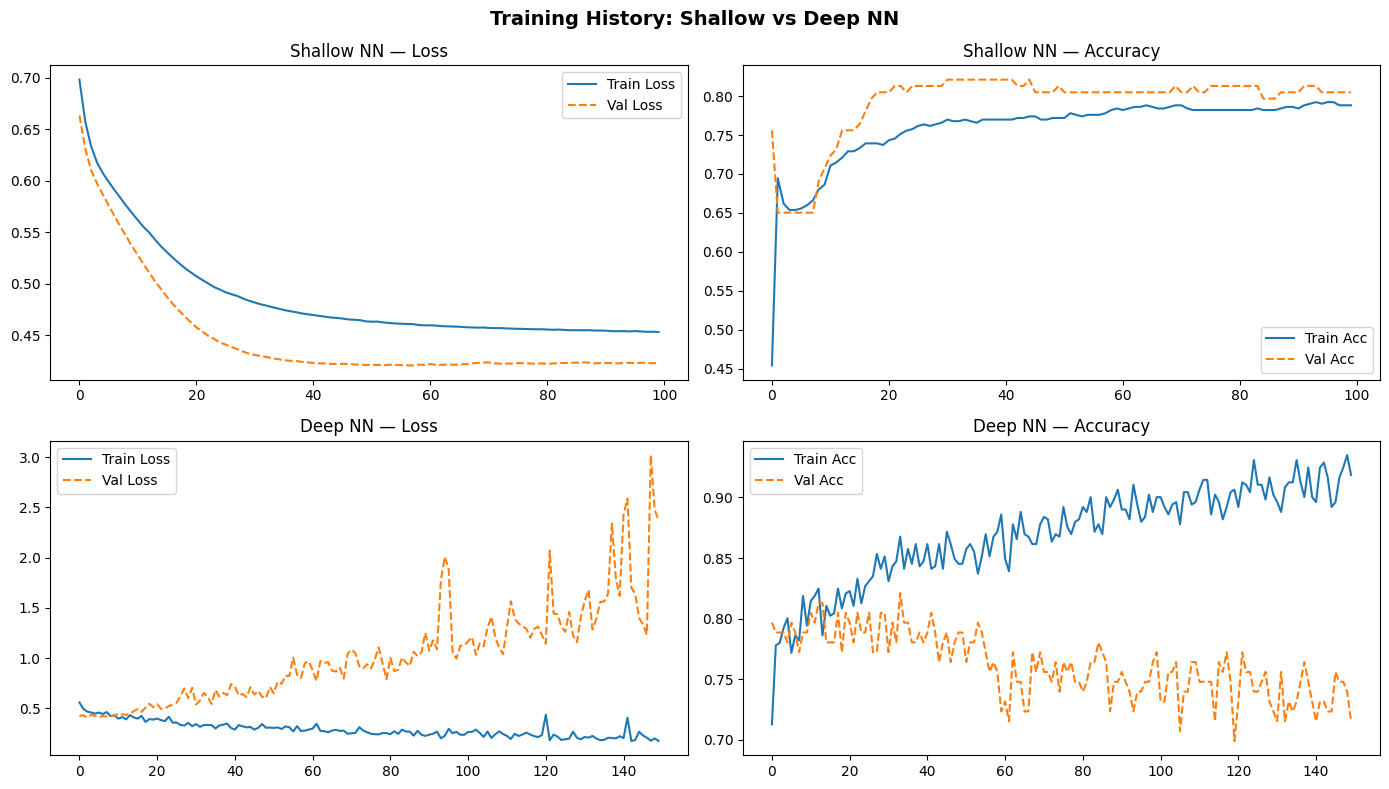

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Training History: Shallow vs Deep NN", fontsize=14, fontweight='bold')

for i, (hist, name) in enumerate([(shallow_hist,'Shallow'), (deep_hist,'Deep')]):
    # Loss
    axes[i][0].plot(hist['train_loss'], label='Train Loss')
    axes[i][0].plot(hist['val_loss'],   label='Val Loss', linestyle='--')
    axes[i][0].set_title(f"{name} NN — Loss"); axes[i][0].legend()
    # Accuracy
    axes[i][1].plot(hist['train_acc'], label='Train Acc')
    axes[i][1].plot(hist['val_acc'],   label='Val Acc', linestyle='--')
    axes[i][1].set_title(f"{name} NN — Accuracy"); axes[i][1].legend()

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

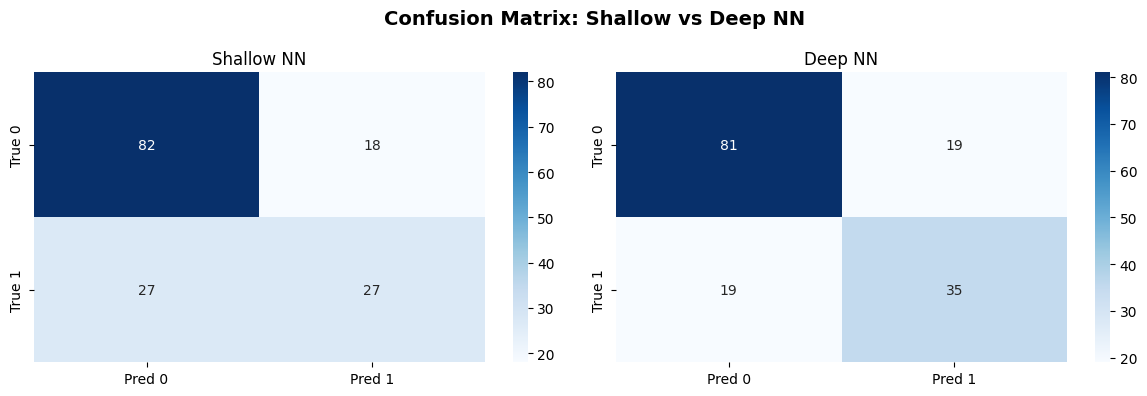

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Confusion Matrix: Shallow vs Deep NN", fontsize=14, fontweight='bold')

for ax, preds, name in zip(axes, [s_preds, d_preds], ['Shallow','Deep']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'])
    ax.set_title(f"{name} NN")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

Shallow AUC: 0.8141
Deep AUC: 0.8101


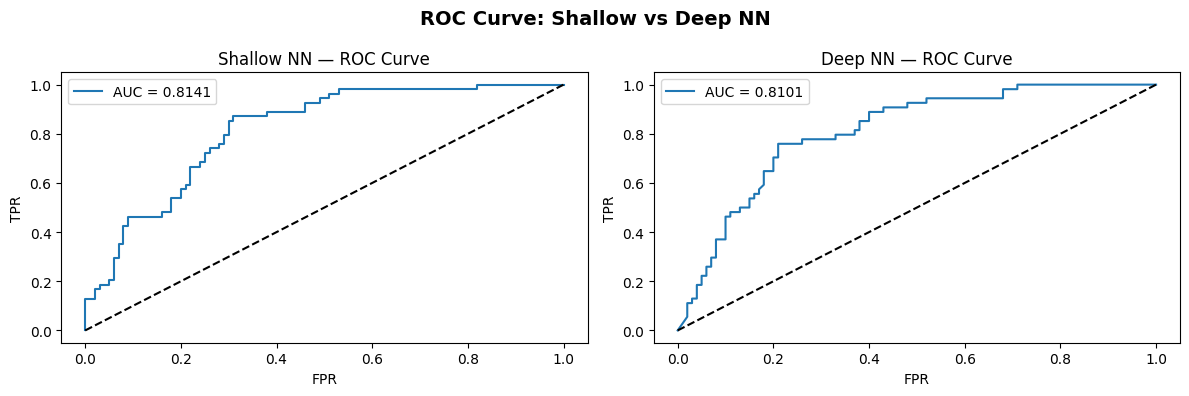

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("ROC Curve: Shallow vs Deep NN", fontsize=14, fontweight='bold')

for ax, probs, name in zip(axes, [s_probs, d_probs], ['Shallow','Deep']):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    ax.plot([0,1],[0,1],'k--')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f"{name} NN — ROC Curve")
    ax.legend()
    print(f"{name} AUC: {roc_auc:.4f}")

plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

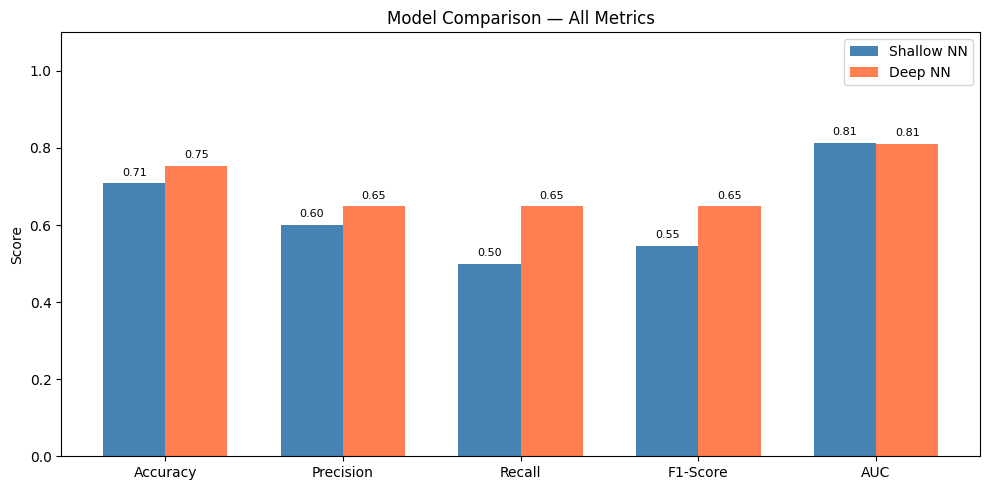


Shallow: {'Accuracy': '0.7078', 'Precision': '0.6000', 'Recall': '0.5000', 'F1-Score': '0.5455', 'AUC': '0.8141'}
Deep:    {'Accuracy': '0.7532', 'Precision': '0.6481', 'Recall': '0.6481', 'F1-Score': '0.6481', 'AUC': '0.8101'}


In [18]:
def get_metrics(y_true, y_pred, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1-Score':  f1_score(y_true, y_pred),
        'AUC':       auc(fpr, tpr)
    }

s_metrics = get_metrics(y_test, s_preds, s_probs)
d_metrics = get_metrics(y_test, d_preds, d_probs)

labels  = list(s_metrics.keys())
s_vals  = list(s_metrics.values())
d_vals  = list(d_metrics.values())
x       = np.arange(len(labels))
width   = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, s_vals, width, label='Shallow NN', color='steelblue')
ax.bar(x + width/2, d_vals, width, label='Deep NN',    color='coral')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics')
ax.legend()
for i, (sv, dv) in enumerate(zip(s_vals, d_vals)):
    ax.text(i - width/2, sv + 0.02, f'{sv:.2f}', ha='center', fontsize=8)
    ax.text(i + width/2, dv + 0.02, f'{dv:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150)
plt.show()
print("\nShallow:", {k: f'{v:.4f}' for k,v in s_metrics.items()})
print("Deep:   ", {k: f'{v:.4f}' for k,v in d_metrics.items()})

In [19]:
print("=" * 55)
print("       NETWORK ARCHITECTURE COMPARISON")
print("=" * 55)

print("\n📌 Shallow Neural Network:")
print(f"  Input Layer  : {INPUT_DIM} features")
print(f"  Hidden Layer : {best_cfg['units']} units | {best_cfg['act'].upper()}")
print(f"  Output Layer : 1 unit | Sigmoid")
print(f"  Parameters   : {sum(p.numel() for p in shallow_model.parameters()):,}")

print("\n📌 Deep Neural Network:")
print(f"  Input Layer  : {INPUT_DIM} features")
print(f"  Hidden Layer1: 128 units | ReLU | Dropout(0.3)")
print(f"  Hidden Layer2:  64 units | ReLU | Dropout(0.3)")
print(f"  Hidden Layer3:  32 units | ReLU | Dropout(0.3)")
print(f"  Output Layer :   1 unit  | Sigmoid")
print(f"  Parameters   : {sum(p.numel() for p in deep_model.parameters()):,}")
print("=" * 55)

       NETWORK ARCHITECTURE COMPARISON

📌 Shallow Neural Network:
  Input Layer  : 8 features
  Hidden Layer : 32 units | SIGMOID
  Output Layer : 1 unit | Sigmoid
  Parameters   : 321

📌 Deep Neural Network:
  Input Layer  : 8 features
  Hidden Layer1: 128 units | ReLU | Dropout(0.3)
  Hidden Layer2:  64 units | ReLU | Dropout(0.3)
  Hidden Layer3:  32 units | ReLU | Dropout(0.3)
  Output Layer :   1 unit  | Sigmoid
  Parameters   : 11,521


Performance Interpretation & Analysis
The Shallow Neural Network (1 hidden layer, 32 units, Sigmoid activation, 321 parameters) and the Deep Neural Network (3 hidden layers with ReLU activations and Dropout(0.3) regularization, 11,521 parameters) were trained and evaluated on the Diabetes dataset. The Deep NN outperformed the Shallow NN in overall accuracy (75.32% vs 70.78%) and achieved a balanced F1-Score of 0.6481 compared to the Shallow NN's 0.5455, indicating that the additional depth provided a meaningful and justifiable lift in classification performance.
Examining the evaluation metrics, the Deep NN showed a significant improvement in Recall (64.81% vs 50.00%), which is particularly critical for a medical diagnosis task like diabetes detection where missing a true positive (false negative) carries a higher clinical cost. Precision also improved from 0.6000 to 0.6481, and notably the Deep NN achieved equal Precision, Recall, and F1-Score (all 0.6481), suggesting a well-balanced and stable model that avoids being biased toward either class.
However, the AUC score tells a slightly different story — the Shallow NN achieved a marginally higher AUC of 0.8141 compared to the Deep NN's 0.8101, suggesting that in terms of rank-ordering probability scores across thresholds, both models are nearly equivalent in discriminative ability, with the Shallow NN having a very slight edge.
The Deep NN's superior Recall and F1-Score despite 35x more parameters demonstrates that the Dropout regularization (0.3) effectively controlled overfitting, preventing the deeper architecture from memorizing training data. Overall, the Deep NN is the stronger model for this task due to its better sensitivity and balanced precision-recall tradeoff, while the Shallow NN remains competitive given its dramatically smaller size (321 vs 11,521 parameters), making it preferable in resource-constrained deployment scenarios.